# Lake Area Analysis Notebook

Converted from your `lake_area_analysis.py` script.

This notebook:
- discovers lake-area files
- loads and inspects them
- converts closed linework to polygons where possible
- computes lake area and boundary length
- compares consecutive maps
- plots area, delta, and boundary overlays
- saves outputs only if `SAVE_OUTPUTS = True`

In [2]:
from pathlib import Path
import re
import unicodedata

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.ops import polygonize

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

TARGET_EPSG = 2056
MIN_AREA_HA = 0.01
SAVE_OUTPUTS = True

REPO_ROOT = Path("../..")

DATA_DIR = REPO_ROOT / "stat_analysis" / "data"
if not DATA_DIR.exists():
    DATA_DIR = Path("../stat_analysis/data")

OUTPUT_DIR = REPO_ROOT / "stat_analysis" / "output" / "lake_analysis_refactored"
if not OUTPUT_DIR.parent.exists():
    OUTPUT_DIR = Path("../stat_analysis/output/lake_analysis")

TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

MAP_ORDER = {
    "melotte": 1721,
    "berney": 1831,
    "renove": 1888,
    "1937": 1937,
    "1959": 1959,
    "contemporain": 2021,
}

MAP_LABELS = {
    "melotte": "Melotte (1721)",
    "berney": "Berney (1831)",
    "renove": "Rénové (1888)",
    "1937": "1937",
    "1959": "1959",
    "contemporain": "Contemporary (2021)",
}

LAKE_COLORS = {
    "melotte": "#000000",
    "berney": "#007AFF",
    "renove": "#34C759",
    "1937": "#FF9F0A",
    "1959": "#FF3B30",
    "contemporain": "#AF52DE",
}

print("DATA_DIR:", DATA_DIR, DATA_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)

DATA_DIR: ../../stat_analysis/data True
OUTPUT_DIR: ../../stat_analysis/output/lake_analysis_refactored
SAVE_OUTPUTS: True


## 1. Helper functions

In [3]:
def normalize_text(value):
    if not isinstance(value, str):
        return ""
    value = value.lower().strip()
    value = "".join(
        c for c in unicodedata.normalize("NFD", value)
        if unicodedata.category(c) != "Mn"
    )
    return value


def infer_map_key(filename):
    lower = normalize_text(filename)

    for key in MAP_ORDER:
        if key in lower:
            return key

    match = re.search(r"\d{4}", lower)
    return match.group() if match else None


def sort_key_for_map(map_key):
    if map_key in MAP_ORDER:
        return MAP_ORDER[map_key]
    if str(map_key).isdigit():
        return int(map_key)
    return 9999


def label_for_map(map_key):
    return MAP_LABELS.get(map_key, str(map_key))


def maybe_save_table(df, path):
    if SAVE_OUTPUTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)
        print("Saved:", path)


def maybe_savefig(path):
    if SAVE_OUTPUTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print("Saved:", path)

## 2. Discover lake area files

In [4]:
def discover_lake_area_files(data_dir):
    supported = {".gpkg", ".geojson", ".shp"}
    files = []

    for path in sorted(data_dir.glob("*")):
        if path.suffix.lower() not in supported:
            continue

        lower = normalize_text(path.name)

        if "area_lake" not in lower:
            continue

        map_key = infer_map_key(path.name)
        if not map_key:
            print(f"SKIP no map key: {path.name}")
            continue

        files.append((map_key, path))
        print(f"FOUND lake area file: {map_key} -> {path.name}")

    return sorted(files, key=lambda x: sort_key_for_map(x[0]))


files = discover_lake_area_files(DATA_DIR)

inventory_rows = []
for map_key, path in files:
    row = {
        "map_key": map_key,
        "map_label": label_for_map(map_key),
        "source_file": path.name,
        "suffix": path.suffix,
        "status": "not_loaded",
        "rows": None,
        "crs": None,
        "geometry_types": None,
        "error": None,
    }

    try:
        gdf = gpd.read_file(path)
        row.update({
            "status": "ok",
            "rows": len(gdf),
            "crs": str(gdf.crs),
            "geometry_types": ", ".join(gdf.geom_type.value_counts().index.astype(str)),
        })
    except Exception as exc:
        row.update({"status": "failed", "error": str(exc)})

    inventory_rows.append(row)

inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)

FOUND lake area file: 1937 -> 1937_area_lake.gpkg
FOUND lake area file: 1937 -> 1937_area_lake_polygon.gpkg
FOUND lake area file: 1937 -> 1937_area_lake_polygon.shp
FOUND lake area file: 1959 -> 1959_area_lake.gpkg
FOUND lake area file: 1959 -> 1959_area_lake_polygon.gpkg
FOUND lake area file: 1959 -> 1959_area_lake_polygon.shp
FOUND lake area file: berney -> berney_area_lake.gpkg
FOUND lake area file: berney -> berney_area_lake_polygon.gpkg
FOUND lake area file: berney -> berney_area_lake_polygon.shp
FOUND lake area file: contemporain -> contemporain_area_lake.gpkg
FOUND lake area file: contemporain -> contemporain_area_lake_polygon.gpkg
FOUND lake area file: contemporain -> contemporain_area_lake_polygon.shp
FOUND lake area file: melotte -> melotte_area_lake.gpkg
FOUND lake area file: melotte -> melotte_area_lake_polygon.gpkg
FOUND lake area file: melotte -> melotte_area_lake_polygon.shp
FOUND lake area file: renove -> renove_area_lake.gpkg
FOUND lake area file: renove -> renove_area

,map_key,map_label,source_file,suffix,status,rows,crs,geometry_types,error
0,melotte,Melotte (1721),melotte_area_lake.gpkg,.gpkg,ok,2,EPSG:2056,MultiLineString,None
1,melotte,Melotte (1721),melotte_area_lake_polygon.gpkg,.gpkg,ok,1,EPSG:2056,MultiPolygon,None
2,melotte,Melotte (1721),melotte_area_lake_polygon.shp,.shp,ok,1,None,Polygon,None
3,berney,Berney (1831),berney_area_lake.gpkg,.gpkg,ok,1,EPSG:2056,MultiLineString,None
4,berney,Berney (1831),berney_area_lake_polygon.gpkg,.gpkg,ok,1,EPSG:2056,MultiPolygon,None
5,berney,Berney (1831),berney_area_lake_polygon.shp,.shp,ok,1,None,Polygon,None
6,renove,Rénové (1888),renove_area_lake.gpkg,.gpkg,ok,1,EPSG:2056,MultiLineString,None
7,renove,Rénové (1888),renove_area_lake_polygon.gpkg,.gpkg,ok,1,EPSG:2056,MultiPolygon,None
8,renove,Rénové (1888),renove_area_lake_polygon.shp,.shp,ok,1,None,Polygon,None
9,1937,1937,1937_area_lake.gpkg,.gpkg,ok,3,EPSG:21781,MultiLineString,None


## 3. Load layers safely

In [5]:
def load_layer(path):
    gdf = gpd.read_file(path)

    # Some shapefiles may miss .prj. Project data is expected to be EPSG:2056.
    if gdf.crs is None:
        print(f"WARNING: Missing CRS for {path.name}; assuming EPSG:2056")
        gdf = gdf.set_crs(epsg=TARGET_EPSG)

    gdf = gdf.to_crs(epsg=TARGET_EPSG)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    gdf["geometry"] = gdf.geometry.make_valid()

    return gdf


loaded_layers = {}

for map_key, path in files:
    try:
        gdf = load_layer(path)
        loaded_layers[(map_key, path.name)] = gdf

        print("\n" + "=" * 80)
        print(path.name)
        print("Rows:", len(gdf))
        print("CRS:", gdf.crs)
        print("Geometry types:")
        print(gdf.geom_type.value_counts())
        display(gdf.head())

    except Exception as exc:
        print("FAILED:", path.name)
        print(exc)


melotte_area_lake.gpkg
Rows: 2
CRS: EPSG:2056
Geometry types:
MultiLineString    2
Name: count, dtype: int64


,id,geometry
0,11,"MULTILINESTRING ((2535909.962 1151626.835, 2535958.683 1151630.603, 2535990.717 1151633.693, 2536035.597 1151639.222, 2536068.932 1151644.913, 2536092.266 1151655.401, 2536116.983 1151666.296, 2536144.383 1151680.687, 2536181.783 1151704.753, 2536227.151 1151734.348, 2536256.421 1151754.512, 2536270.893 1151763.943, 2536278.373 1151766.707, 2536308.293 1151763.455, 2536340.977 1151757.601, 2536381.142 1151743.454, 2536433.827 1151723.616, 2536479.683 1151704.428, 2536518.059 1151688.33, 2536542.288 1151676.622, 2536570.744 1151665.076, 2536595.136 1151652.393, 2536675.79 1151601.821, 2536708.149 1151585.723, 2536738.069 1151571.088, 2536753.843 1151563.446, 2536780.185 1151554.99, 2536801.162 1151548.811, 2536817.911 1151540.192, 2536847.993 1151522.631, 2536878.076 1151507.833, 2536908.321 1151494.987, 2536954.99 1151460.514, 2536993.366 1151437.749, 2537017.107 1151416.609, 2537042.637 1151393.194, 2537071.419 1151369.453, 2537092.72 1151349.452, 2537135.812 1151308.474, 2537188.497 1151263.757))"
1,12,"MULTILINESTRING ((2537188.497 1151263.757, 2537266.387 1151187.757, 2537491.764 1151048.726, 2537622.014 1150948.477, 2537674.882 1150900.548, 2537691.346 1150886.279, 2537691.346 1150881.523, 2537735.068 1150861.4, 2537756.654 1150850.973, 2537761.319 1150857.467, 2537744.078 1150864.693, 2537731.181 1150870.913, 2537719.336 1150876.675, 2537716.134 1150878.184, 2537713.207 1150878.596, 2537707.902 1150881.797, 2537705.844 1150884.038, 2537705.981 1150886.92, 2537707.628 1150890.029, 2537710.166 1150892.316, 2537714.328 1150890.853, 2537718.146 1150888.383, 2537719.656 1150886.782, 2537719.816 1150885.365, 2537724.526 1150885.502, 2537728.162 1150885.25, 2537729.923 1150884.724, 2537737.469 1150882.049, 2537744.329 1150879.351, 2537752.79 1150876.195, 2537759.147 1150874, 2537761.571 1150876.972, 2537764.772 1150878.71, 2537768.842 1150878.665, 2537770.306 1150876.972, 2537770.992 1150874.32, 2537770.9 1150870.89, 2537769.528 1150867.323, 2537774.285 1150872.856, 2537782.563 1150882.964, 2537795.46 1150886.714, 2537813.707 1150893.116, 2537827.702 1150898.787, 2537849.288 1150907.02, 2537861.545 1150909.764, 2537873.619 1150922.386, 2537936.823 1150955.955, 2537941.213 1150964.736, 2537940.116 1150971.321, 2537960.605 1150983.029, 2538007.436 1150984.493, 2538059.756 1150989.615, 2538090.184 1150991.414, 2538113.234 1150990.682, 2538197.018 1150966.779, 2538253.118 1150940.436, 2538290.193 1150924.337, 2538335.561 1150902.385, 2538380.929 1150882.872, 2538435.078 1150869.945, 2538469.226 1150860.432, 2538508.496 1150848.846, 2538550.572 1150833.479, 2538625.453 1150806.039, 2538658.26 1150791.892, 2538714.238 1150768.111, 2538747.898 1150755.671, 2538773.997 1150752.256, 2538784.607 1150752.866, 2538796.193 1150751.646, 2538807.657 1150744.085, 2538828.634 1150736.524))"



melotte_area_lake_polygon.gpkg
Rows: 1
CRS: EPSG:2056
Geometry types:
MultiPolygon    1
Name: count, dtype: int64


,geometry
0,"MULTIPOLYGON (((2538828.634 1150736.524, 2538874.456 1150198.528, 2535789.235 1151407.316, 2535909.962 1151626.835, 2535990.717 1151633.693, 2536068.932 1151644.913, 2536092.266 1151655.401, 2536116.983 1151666.296, 2536181.783 1151704.753, 2536278.373 1151766.707, 2536340.977 1151757.601, 2536381.142 1151743.454, 2536518.059 1151688.33, 2536570.744 1151665.076, 2536595.136 1151652.393, 2536675.79 1151601.821, 2536738.069 1151571.088, 2536753.843 1151563.446, 2536780.185 1151554.99, 2536801.162 1151548.811, 2536847.993 1151522.631, 2536878.076 1151507.833, 2536908.321 1151494.987, 2536954.99 1151460.514, 2537017.107 1151416.609, 2537266.387 1151187.757, 2537491.764 1151048.726, 2537622.014 1150948.477, 2537691.346 1150886.279, 2537691.346 1150881.523, 2537756.654 1150850.973, 2537761.319 1150857.467, 2537716.134 1150878.184, 2537707.902 1150881.797, 2537705.981 1150886.92, 2537710.166 1150892.316, 2537718.146 1150888.383, 2537719.816 1150885.365, 2537728.162 1150885.25, 2537759.147 1150874, 2537761.571 1150876.972, 2537764.772 1150878.71, 2537768.842 1150878.665, 2537770.992 1150874.32, 2537769.528 1150867.323, 2537782.563 1150882.964, 2537849.288 1150907.02, 2537861.545 1150909.764, 2537873.619 1150922.386, 2537936.823 1150955.955, 2537940.116 1150971.321, 2537960.605 1150983.029, 2538007.436 1150984.493, 2538059.756 1150989.615, 2538113.234 1150990.682, 2538197.018 1150966.779, 2538253.118 1150940.436, 2538380.929 1150882.872, 2538435.078 1150869.945, 2538469.226 1150860.432, 2538625.453 1150806.039, 2538658.26 1150791.892, 2538747.898 1150755.671, 2538773.997 1150752.256, 2538784.607 1150752.866, 2538796.193 1150751.646, 2538807.657 1150744.085, 2538828.634 1150736.524)))"



melotte_area_lake_polygon.shp
Rows: 1
CRS: EPSG:2056
Geometry types:
Polygon    1
Name: count, dtype: int64


...

id  length  \
0 NaN     NaN   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                


contemporain_area_lake_polygon.gpkg
Rows: 1
CRS: EPSG:2056
Geometry types:
MultiPolygon    1
Name: count, dtype: int64


geometry
0  MULTIPOLYGON (((2538882.687 1150699.266, 2538875.09 1150198.265, 2535790.068 1151408.907, 2535854.432 1151485.095, 2536079.618 1151406.381, 2536295.397 1151424.898, 2536301.538 1151422.064, 2536306.923 1151435.196, 2536302.01 1151437.841, 2536294.641 1151431.795, 2536080.374 1151414.978, 2535996.67 1151444.643, 2535994.969 1151450.689, 2535998.37 1151468.073, 2536031.342 1151463.916, 2536032.948 1151474.875, 2535998.37 1151479.032, 2536015.754 1151585.032, 2536225.486 1151589.188, 2536227.753 1151577.852, 2536222.841 1151577.285, 2536232.194 1151528.819, 2536237.579 1151529.481, 2536239.657 1151517.199, 2536234.367 1151516.16, 2536239.752 1151489.707, 2536261.103 1151489.518, 2536281.887 1151520.6, 2536308.529 1151495.376, 2536323.739 1151473.741, 2536322.369 1151466.514, 2536327.943 1151462.877, 2536332.62 1151463.963, 2536337.343 1151469.631, 2536353.593 1151469.679, 2536369.89 1151465.38, 2536383.824 1151456.877, 2536386.47 1151462.64, 2536393.225 1151462.971, 2536400.31 1151461.648, 2536411.553 1151455.791, 2536427.613 1151443.037, 2536429.786 1151449.272, 2536436.683 1151450.406, 2536451.326 1151449.083, 2536463.891 1151442.848, 2536477.779 1151432.456, 2536486.66 1151436.329, 2536497.855 1151435.621, 2536511.884 1151429.669, 2536526.622 1151420.41, 2536528.7 1151425.607, 2536541.549 1151426.74, 2536556.192 1151421.733, 2536571.025 1151410.302, 2536572.725 1151415.12, 2536579.811 1151415.592, 2536601.54 1151408.885, 2536616.939 1151396.603, 2536620.34 1151403.405, 2536629.504 1151402.177, 2536637.535 1151399.437, 2536645.659 1151394.525, 2536660.397 1151384.699, 2536666.444 1151375.819, 2536669.089 1151381.487, 2536672.49 1151382.432, 2536679.859 1151381.676, 2536689.495 1151376.952, 2536708.579 1151361.27, 2536715.287 1151350.783, 2536723.884 1151357.113, 2536734.654 1151351.161, 2536737.866 1151348.705, 2536747.786 1151340.863, 2536754.21 1151333.872, 2536760.445 1151325.086, 2536762.051 1151325.086, 2536765.264 1151328.582, 2536769.704 1151328.298, 2536782.883 1151320.173, 2536792.708 1151311.198, 2536808.391 1151290.32, 2536810.375 1151293.059, 2536819.917 1151290.509, 2536839.709 1151273.551, 2536854.636 1151254.183, 2536824.782 1151197.31, 2536886.852 1151155.93, 2536961.392 1151077.328, 2537031.586 1151003.26, 2537067.108 1150969.061, 2537115.003 1150929.668, 2537135.672 1150921.98, 2537093.75 1150955.362, 2537059.739 1150985.594, 2537018.171 1151027.729, 2537017.037 1151029.335, 2537024.5 1151036.893, 2536966.399 1151097.829, 2536997.008 1151132.595, 2536993.418 1151136.28, 2537007.401 1151152.151, 2537011.746 1151148.467, 2537052.654 1151193.153, 2537117.935 1151140.72, 2537125.493 1151150.073, 2537259.457 1151030.091, 2537237.917 1151005.339, 2537245.003 1151007.228, 2537249.065 1150994.663, 2537240.752 1150992.112, 2537248.404 1150969.533, 2537238.39 1150966.274, 2537239.523 1150962.542, 2537241.744 1150960.322, 2537266.165 1150969.958, 2537273.251 1150947.662, 2537276.321 1150946.103, 2537281.234 1150947.237, 2537282.084 1150950.119, 2537275.66 1150968.824, 2537273.298 1150972.414, 2537272.211 1150976.146, 2537305.325 1150987.341, 2537303.813 1150991.498, 2537335.722 1151002.245, 2537337.28 1150998.56, 2537428.637 1151036.303, 2537617.774 1150866.674, 2537613.428 1150854.015, 2537619.097 1150852.125, 2537598.596 1150771.067, 2537580.551 1150775.601, 2537576.961 1150780.231, 2537572.426 1150778.152, 2537594.226 1150751.417, 2537619.775 1150741.913, 2537642.999 1150831.436, 2537653.863 1150828.743, 2537675.403 1150808.006, 2537675.923 1150800.873, 2537679.607 1150798.7, 2537683.197 1150801.109, 2537725.569 1150763.461, 2537710.411 1150708.2, 2537746.543 1150694.761, 2537764.776 1150705.643, 2537778.474 1150713.674, 2537827.034 1150735.403, 2537859.533 1150748.44, 2537861.517 1150751.652, 2537862.556 1150763.556, 2537861.328 1150765.162, 2537857.644 1150764.312, 2537852.92 1150759.21, 2537840.827 1150769.791, 2537838.371 1150770.264, 2537835.253 1150769.319, 2537786.316 1150814.95, 2537788.583 1150816


contemporain_area_lake_polygon.shp
Rows: 1
CRS: EPSG:2056
Geometry types:
Polygon    1
Name: count, dtype: int64


geometry
0  POLYGON ((2538882.687 1150699.266, 2538875.09 1150198.265, 2535790.068 1151408.907, 2535854.432 1151485.095, 2536079.618 1151406.381, 2536295.397 1151424.898, 2536301.538 1151422.064, 2536306.923 1151435.196, 2536302.01 1151437.841, 2536294.641 1151431.795, 2536080.374 1151414.978, 2535996.67 1151444.643, 2535994.969 1151450.689, 2535998.37 1151468.073, 2536031.342 1151463.916, 2536032.948 1151474.875, 2535998.37 1151479.032, 2536015.754 1151585.032, 2536225.486 1151589.188, 2536227.753 1151577.852, 2536222.841 1151577.285, 2536232.194 1151528.819, 2536237.579 1151529.481, 2536239.657 1151517.199, 2536234.367 1151516.16, 2536239.752 1151489.707, 2536261.103 1151489.518, 2536281.887 1151520.6, 2536308.529 1151495.376, 2536323.739 1151473.741, 2536322.369 1151466.514, 2536327.943 1151462.877, 2536332.62 1151463.963, 2536337.343 1151469.631, 2536353.593 1151469.679, 2536369.89 1151465.38, 2536383.824 1151456.877, 2536386.47 1151462.64, 2536393.225 1151462.971, 2536400.31 1151461.648, 2536411.553 1151455.791, 2536427.613 1151443.037, 2536429.786 1151449.272, 2536436.683 1151450.406, 2536451.326 1151449.083, 2536463.891 1151442.848, 2536477.779 1151432.456, 2536486.66 1151436.329, 2536497.855 1151435.621, 2536511.884 1151429.669, 2536526.622 1151420.41, 2536528.7 1151425.607, 2536541.549 1151426.74, 2536556.192 1151421.733, 2536571.025 1151410.302, 2536572.725 1151415.12, 2536579.811 1151415.592, 2536601.54 1151408.885, 2536616.939 1151396.603, 2536620.34 1151403.405, 2536629.504 1151402.177, 2536637.535 1151399.437, 2536645.659 1151394.525, 2536660.397 1151384.699, 2536666.444 1151375.819, 2536669.089 1151381.487, 2536672.49 1151382.432, 2536679.859 1151381.676, 2536689.495 1151376.952, 2536708.579 1151361.27, 2536715.287 1151350.783, 2536723.884 1151357.113, 2536734.654 1151351.161, 2536737.866 1151348.705, 2536747.786 1151340.863, 2536754.21 1151333.872, 2536760.445 1151325.086, 2536762.051 1151325.086, 2536765.264 1151328.582, 2536769.704 1151328.298, 2536782.883 1151320.173, 2536792.708 1151311.198, 2536808.391 1151290.32, 2536810.375 1151293.059, 2536819.917 1151290.509, 2536839.709 1151273.551, 2536854.636 1151254.183, 2536824.782 1151197.31, 2536886.852 1151155.93, 2536961.392 1151077.328, 2537031.586 1151003.26, 2537067.108 1150969.061, 2537115.003 1150929.668, 2537135.672 1150921.98, 2537093.75 1150955.362, 2537059.739 1150985.594, 2537018.171 1151027.729, 2537017.037 1151029.335, 2537024.5 1151036.893, 2536966.399 1151097.829, 2536997.008 1151132.595, 2536993.418 1151136.28, 2537007.401 1151152.151, 2537011.746 1151148.467, 2537052.654 1151193.153, 2537117.935 1151140.72, 2537125.493 1151150.073, 2537259.457 1151030.091, 2537237.917 1151005.339, 2537245.003 1151007.228, 2537249.065 1150994.663, 2537240.752 1150992.112, 2537248.404 1150969.533, 2537238.39 1150966.274, 2537239.523 1150962.542, 2537241.744 1150960.322, 2537266.165 1150969.958, 2537273.251 1150947.662, 2537276.321 1150946.103, 2537281.234 1150947.237, 2537282.084 1150950.119, 2537275.66 1150968.824, 2537273.298 1150972.414, 2537272.211 1150976.146, 2537305.325 1150987.341, 2537303.813 1150991.498, 2537335.722 1151002.245, 2537337.28 1150998.56, 2537428.637 1151036.303, 2537617.774 1150866.674, 2537613.428 1150854.015, 2537619.097 1150852.125, 2537598.596 1150771.067, 2537580.551 1150775.601, 2537576.961 1150780.231, 2537572.426 1150778.152, 2537594.226 1150751.417, 2537619.775 1150741.913, 2537642.999 1150831.436, 2537653.863 1150828.743, 2537675.403 1150808.006, 2537675.923 1150800.873, 2537679.607 1150798.7, 2537683.197 1150801.109, 2537725.569 1150763.461, 2537710.411 1150708.2, 2537746.543 1150694.761, 2537764.776 1150705.643, 2537778.474 1150713.674, 2537827.034 1150735.403, 2537859.533 1150748.44, 2537861.517 1150751.652, 2537862.556 1150763.556, 2537861.328 1150765.162, 2537857.644 1150764.312, 2537852.92 1150759.21, 2537840.827 1150769.791, 2537838.371 1150770.264, 2537835.253 1150769.319, 2537786.316 1150814.95, 2537788.583 1150816.367, 

## 4. Polygon creation

In [6]:
def polygonize_lake_lines(gdf):
    geom_types = set(gdf.geom_type.unique())

    if geom_types & {"Polygon", "MultiPolygon"}:
        polygons = gdf[gdf.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
        polygons = polygons[["geometry"]].copy()
        polygons["area_m2"] = polygons.geometry.area
        polygons["area_ha"] = polygons["area_m2"] / 10_000
        return polygons

    linework = gdf.geometry.union_all()
    polygons = list(polygonize(linework))

    if not polygons:
        return gpd.GeoDataFrame(geometry=[], crs=gdf.crs)

    out = gpd.GeoDataFrame(geometry=polygons, crs=gdf.crs)
    out["area_m2"] = out.geometry.area
    out["area_ha"] = out["area_m2"] / 10_000

    # Remove tiny sliver polygons.
    out = out[out["area_ha"] >= MIN_AREA_HA].copy()

    return out


def choose_main_lake_polygon(polygons):
    if polygons.empty:
        return polygons

    polygons = polygons.copy()
    polygons["area_m2"] = polygons.geometry.area
    polygons["area_ha"] = polygons["area_m2"] / 10_000

    largest = polygons.sort_values("area_m2", ascending=False).head(1)
    return largest[["geometry", "area_m2", "area_ha"]].copy()

## 5. Build lake area analysis

In [7]:
def build_lake_area_analysis(files):
    lake_polygons = {}
    rows = []

    for map_key, path in files:
        try:
            gdf = load_layer(path)
        except Exception as exc:
            print(f"WARNING: failed loading {path.name}: {exc}")
            rows.append({
                "map_key": map_key,
                "map_label": label_for_map(map_key),
                "source_file": path.name,
                "polygon_created": False,
                "polygon_count": 0,
                "area_m2": np.nan,
                "area_ha": np.nan,
                "boundary_length_m": np.nan,
                "error": str(exc),
            })
            continue

        polygons = polygonize_lake_lines(gdf)
        main_poly = choose_main_lake_polygon(polygons)

        if main_poly.empty:
            print(f"WARNING: no usable polygon could be created for {path.name}")
            rows.append({
                "map_key": map_key,
                "map_label": label_for_map(map_key),
                "source_file": path.name,
                "polygon_created": False,
                "polygon_count": 0,
                "area_m2": np.nan,
                "area_ha": np.nan,
                "boundary_length_m": gdf.geometry.length.sum(),
                "error": None,
            })
            continue

        geom = main_poly.geometry.iloc[0]

        if geom is None or geom.is_empty:
            print(f"WARNING: empty polygon for {path.name}")
            continue

        # If both GPKG and SHP exist for the same map, prefer SHP polygon files.
        old = lake_polygons.get(map_key)
        if old is None or path.suffix.lower() == ".shp":
            lake_polygons[map_key] = geom

        rows.append({
            "map_key": map_key,
            "map_label": label_for_map(map_key),
            "source_file": path.name,
            "polygon_created": True,
            "polygon_count": len(polygons),
            "area_m2": geom.area,
            "area_ha": geom.area / 10_000,
            "boundary_length_m": geom.boundary.length,
            "error": None,
        })

    area_df = pd.DataFrame(rows)

    if not area_df.empty:
        area_df["sort_key"] = area_df["map_key"].apply(sort_key_for_map)
        area_df = area_df.sort_values(["sort_key", "source_file"])

    return area_df, lake_polygons


area_df, lake_polygons = build_lake_area_analysis(files)

display(area_df)
maybe_save_table(area_df, TABLES_DIR / "lake_area_by_map.csv")

,map_key,map_label,source_file,polygon_created,polygon_count,area_m2,area_ha,boundary_length_m,error,sort_key
0,melotte,Melotte (1721),melotte_area_lake.gpkg,False,0,NaN,NaN,3472.007897,None,1721
1,melotte,Melotte (1721),melotte_area_lake_polygon.gpkg,True,1,1.318230e+06,131.823039,7572.895982,None,1721
2,melotte,Melotte (1721),melotte_area_lake_polygon.shp,True,1,1.318230e+06,131.823039,7572.895982,None,1721
3,berney,Berney (1831),berney_area_lake.gpkg,False,0,NaN,NaN,3580.045421,None,1831
4,berney,Berney (1831),berney_area_lake_polygon.gpkg,True,1,1.375956e+06,137.595631,7667.288947,None,1831
5,berney,Berney (1831),berney_area_lake_polygon.shp,True,1,1.375956e+06,137.595631,7667.288947,None,1831
6,renove,Rénové (1888),renove_area_lake.gpkg,True,1,1.310513e+06,131.051327,8068.015497,None,1888
7,renove,Rénové (1888),renove_area_lake_polygon.gpkg,True,1,1.310513e+06,131.051327,8068.015497,None,1888
8,renove,Rénové (1888),renove_area_lake_polygon.shp,True,1,1.310513e+06,131.051327,8068.015497,None,1888
9,1937,1937,1937_area_lake.gpkg,False,0,NaN,NaN,4247.293038,None,1937


Saved: ../../stat_analysis/output/lake_analysis_refactored/tables/lake_area_by_map.csv


## 6. Pairwise lake area change

In [8]:
def build_pairwise_lake_change(lake_polygons):
    ordered = sorted(lake_polygons.keys(), key=sort_key_for_map)
    rows = []

    for a, b in zip(ordered[:-1], ordered[1:]):
        geom_a = lake_polygons[a]
        geom_b = lake_polygons[b]

        stable = geom_a.intersection(geom_b)
        lost = geom_a.difference(geom_b)
        gained = geom_b.difference(geom_a)

        rows.append({
            "period": f"{label_for_map(a)} → {label_for_map(b)}",
            "map_start": a,
            "map_end": b,
            "area_start_m2": geom_a.area,
            "area_end_m2": geom_b.area,
            "delta_area_m2": geom_b.area - geom_a.area,
            "delta_area_ha": (geom_b.area - geom_a.area) / 10_000,
            "stable_area_m2": stable.area,
            "lost_area_m2": lost.area,
            "gained_area_m2": gained.area,
            "lost_area_ha": lost.area / 10_000,
            "gained_area_ha": gained.area / 10_000,
            "max_boundary_displacement_m": geom_a.boundary.hausdorff_distance(geom_b.boundary),
        })

    return pd.DataFrame(rows)


pairwise_df = build_pairwise_lake_change(lake_polygons)
display(pairwise_df)
maybe_save_table(pairwise_df, TABLES_DIR / "lake_area_pairwise_change.csv")

,period,map_start,map_end,area_start_m2,area_end_m2,delta_area_m2,delta_area_ha,stable_area_m2,lost_area_m2,gained_area_m2,lost_area_ha,gained_area_ha,max_boundary_displacement_m
0,Melotte (1721) → Berney (1831),melotte,berney,1.318230e+06,1.375956e+06,57725.917601,5.772592,1.290557e+06,2.767364e+04,8.539956e+04,2.767364,8.539956,1.474086e+02
1,Berney (1831) → Rénové (1888),berney,renove,1.375956e+06,1.310513e+06,-65443.041089,-6.544304,1.302226e+06,7.373014e+04,8.287099e+03,7.373014,0.828710,1.490521e+02
2,Rénové (1888) → 1937,renove,1937,1.310513e+06,1.167445e+06,-143067.846010,-14.306785,0.000000e+00,1.310513e+06,1.167445e+06,131.051327,116.744542,2.236076e+06
3,1937 → 1959,1937,1959,1.167445e+06,1.175391e+06,7945.125928,0.794513,0.000000e+00,1.167445e+06,1.175391e+06,116.744542,117.539055,2.236068e+06
4,1959 → Contemporary (2021),1959,contemporain,1.175391e+06,9.374009e+05,-237989.676156,-23.798968,9.232170e+05,2.521736e+05,1.418392e+04,25.217360,1.418392,2.484810e+02


Saved: ../../stat_analysis/output/lake_analysis_refactored/tables/lake_area_pairwise_change.csv


## 7. Plot lake area over time

Saved: ../../stat_analysis/output/lake_analysis_refactored/figures/lake_area_over_time.png


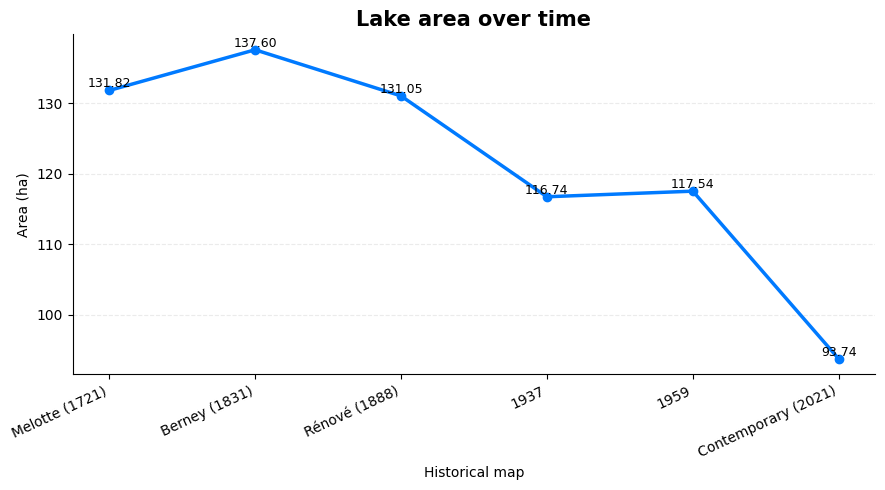

In [9]:
def plot_lake_area(area_df, out_path=None):
    clean = area_df.dropna(subset=["area_ha"]).copy()

    # If multiple sources exist per map, keep largest valid area.
    clean = clean.sort_values(["map_key", "area_ha"], ascending=[True, False])
    clean = clean.groupby("map_key", as_index=False).first()
    clean["sort_key"] = clean["map_key"].apply(sort_key_for_map)
    clean = clean.sort_values("sort_key")

    if clean.empty:
        print("No area data to plot.")
        return

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(clean["map_label"], clean["area_ha"], marker="o", linewidth=2.5, color="#007AFF")

    ax.set_title("Lake area over time", fontsize=15, fontweight="bold")
    ax.set_xlabel("Historical map")
    ax.set_ylabel("Area (ha)")
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for x, y in zip(clean["map_label"], clean["area_ha"]):
        ax.text(x, y, f"{y:.2f}", ha="center", va="bottom", fontsize=9)

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    if out_path is not None:
        maybe_savefig(out_path)

    plt.show()


plot_lake_area(area_df, FIGURES_DIR / "lake_area_over_time.png")

## 8. Plot lake area delta

Saved: ../../stat_analysis/output/lake_analysis_refactored/figures/lake_area_delta.png


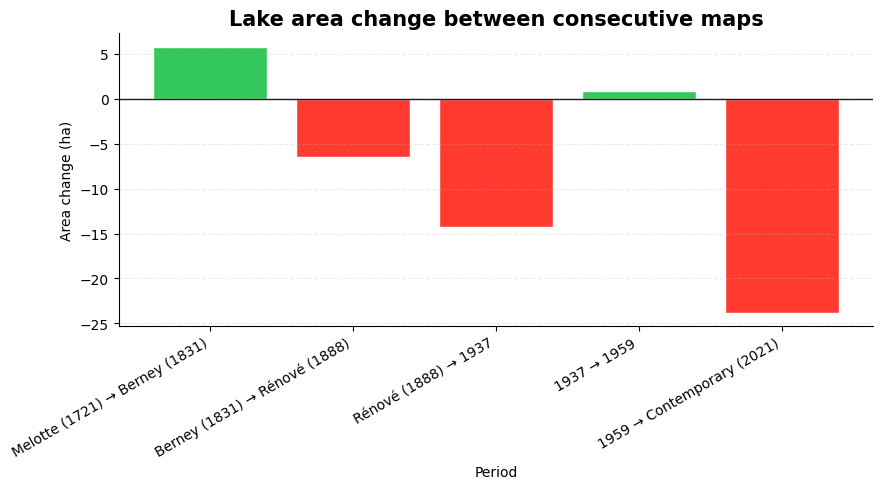

In [10]:
def plot_lake_delta(pairwise_df, out_path=None):
    if pairwise_df.empty:
        print("No pairwise data to plot.")
        return

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ["#34C759" if v >= 0 else "#FF3B30" for v in pairwise_df["delta_area_ha"]]

    ax.bar(pairwise_df["period"], pairwise_df["delta_area_ha"], color=colors, edgecolor="white", linewidth=1)
    ax.axhline(0, linewidth=1, color="#1C1C1E")

    ax.set_title("Lake area change between consecutive maps", fontsize=15, fontweight="bold")
    ax.set_xlabel("Period")
    ax.set_ylabel("Area change (ha)")
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    if out_path is not None:
        maybe_savefig(out_path)

    plt.show()


plot_lake_delta(pairwise_df, FIGURES_DIR / "lake_area_delta.png")

## 9. Plot lake boundary overlay

Saved: ../../stat_analysis/output/lake_analysis_refactored/figures/lake_boundary_overlay.png


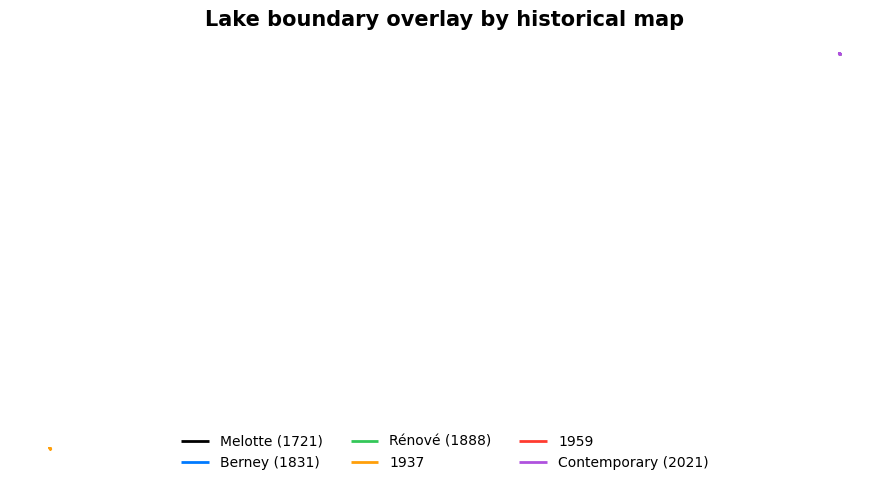

In [11]:
def plot_lake_overlay(lake_polygons, out_path=None):
    if not lake_polygons:
        print("No lake polygons to plot.")
        return

    fig, ax = plt.subplots(figsize=(9, 8))

    for map_key in sorted(lake_polygons.keys(), key=sort_key_for_map):
        gpd.GeoSeries([lake_polygons[map_key]], crs=f"EPSG:{TARGET_EPSG}").boundary.plot(
            ax=ax,
            linewidth=2,
            color=LAKE_COLORS.get(map_key, "#8E8E93"),
            label=label_for_map(map_key),
        )

    ax.set_title("Lake boundary overlay by historical map", fontsize=15, fontweight="bold")
    ax.set_axis_off()
    ax.set_aspect("equal")

    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=3, frameon=False)

    plt.tight_layout(rect=[0, 0.07, 1, 1])

    if out_path is not None:
        maybe_savefig(out_path)

    plt.show()


plot_lake_overlay(lake_polygons, FIGURES_DIR / "lake_boundary_overlay.png")

## 10. Save outputs

Set:

```python
SAVE_OUTPUTS = True
```

near the top of the notebook, then rerun all cells.